#### NAME : WAJAHAT TAJ 
#### ROll NO : 23P-3023
#### SECTION : BS-SE-5A
#### ASSIGNMENT NO : 03

#### Dataset Information
•Dataset File: air_quality_data.csv

•Dataset Description:

The dataset contains daily air quality measurements collected over a year. It includes:

• Pollutant Levels: Measurements of pollutants like PM2.5, PM10, NO2, and O3.

• No: Record number.

• Timestamp of the measurement: year, month, day, hour

• Pollutant levels: PM2.5, PM10, SO2, NO2, CO, O3.

• Weather Data: TEMP, PRES, DEWP, RAIN, wd, WSPM (temperature, pressure, dew point, rain, wind direction, wind speed).

• Station: Monitoring station name.

In [89]:
import numpy as ndfp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('air_quality_data.csv')


### EDA Operations

##### Basic Structure Checking

In [90]:

print("Data set shape : \n" , df.shape)

print("\nData set tail : \n" , df.tail())

print("\nData set column names \n" , df.columns.tolist())

print("\nData set Info : \n" , df.info())

print("\nData set Describe : \n", df.describe())

print("\nData Types : \n" , df.dtypes)




Data set shape : 
 (35064, 18)

Data set tail : 
           No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  \
35059  35060  2017      2   28    19   12.0  29.0   5.0  35.0  400.0  95.0   
35060  35061  2017      2   28    20   13.0  37.0   7.0  45.0  500.0  81.0   
35061  35062  2017      2   28    21   16.0  37.0  10.0  66.0  700.0  58.0   
35062  35063  2017      2   28    22   21.0  44.0  12.0  87.0  700.0  35.0   
35063  35064  2017      2   28    23   19.0  31.0  10.0  79.0  600.0  42.0   

       TEMP    PRES  DEWP  RAIN   wd  WSPM       station  
35059  12.5  1013.5 -16.2   0.0   NW   2.4  Aotizhongxin  
35060  11.6  1013.6 -15.1   0.0  WNW   0.9  Aotizhongxin  
35061  10.8  1014.2 -13.3   0.0   NW   1.1  Aotizhongxin  
35062  10.5  1014.4 -12.9   0.0  NNW   1.2  Aotizhongxin  
35063   8.6  1014.1 -15.9   0.0  NNE   1.3  Aotizhongxin  

Data set column names 
 ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEW

##### Missing Values Analysis

In [91]:
print("Missing values : \n" , df.isnull().sum()) 

missing_data = df.isnull().sum()
print("\n\nMissing values per column : ")
print(missing_data[missing_data > 0])

print("\n\nMissing Values mean : \n" , df.isnull().mean() * 100)


Missing values : 
 No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64


Missing values per column : 
PM2.5     925
PM10      718
SO2       935
NO2      1023
CO       1776
O3       1719
TEMP       20
PRES       20
DEWP       20
RAIN       20
wd         81
WSPM       14
dtype: int64


Missing Values mean : 
 No         0.000000
year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.638033
PM10       2.047684
SO2        2.666553
NO2        2.917522
CO         5.065024
O3         4.902464
TEMP       0.057039
PRES       0.057039
DEWP       0.057039
RAIN       0.057039
wd         0.231006
WSPM       0.039927
station    0.000000
dtype: float64


##### Duplicate Data Analysis

In [92]:
print("Check for the Duplicates : " , df.duplicated().sum())


Check for the Duplicates :  0


#### Section 1: Data Cleaning
1.Identify Issues:

•Identify and document any missing values, outliers, or inconsistencies in the dataset.

•For example, check for negative pollutant levels or unrealistic weather data.

2.Handle Missing Values and Outliers:

•Handle missing values using appropriate methods (e.g., mean, median, or interpolation).

•Handle outliers by either removing or adjusting them.

•Justify your approach in a Markdown cell.

##### • Identify and document any missing values, outliers, or inconsistencies in the dataset.
##### • For example, check for negative pollutant levels or unrealistic weather data.

In [93]:
print("Data Quality Check : \n")

print(f"Records with negative pollutants : {len(df[df['PM2.5'] < 0] )}\n")

print(f"Temperature range : {df['TEMP'].min()} to {df['TEMP'].max()} C\n")

print(f"Pressure range: {df['PRES'].min()} to {df['PRES'].max()} hPa\n")

print(f"PM2.5 range: {df['PM2.5'].min()} to {df['PM2.5'].max()} μg/m^3\n")

# 2. Handle unrealistic values (negative pollutants)
pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3' , 'PRES']
df[pollutant_cols] = df[pollutant_cols].clip(lower=0)

Data Quality Check : 

Records with negative pollutants : 0

Temperature range : -16.8 to 40.5 C

Pressure range: 985.9 to 1042.0 hPa

PM2.5 range: 3.0 to 898.0 μg/m^3



#### 2 . Handle Missing Values and Outliers

##### • Handle missing values using appropriate methods (e.g., mean, median, or interpolation).

##### • Handle outliers by either removing or adjusting them.

##### • Justify your approach in a Markdown cell.

In [94]:
# # Sort by timestamp (CRUCIAL for time-series interpolation)
df = df.sort_values(['year' , 'month' , 'day' , 'hour'])

#  the numerical column interpolation
numerical_columns = ['PM2.5' , 'PM10' , 'SO2' , 'NO2' , 'Co' , 'O3' , 'TEMP' , 'PRES' , 'DEWP' , 'RAIN' , 'WSPM']

 # 3. Interpolate numerical columns
numerical_cols = pollutant_cols + ['TEMP', 'DEWP', 'RAIN', 'WSPM'] # after removing the negative values we addded the pollutant_col to the numerical again

df[numerical_cols] = df[numerical_cols].interpolate(
    method='linear',
    limit_direction='both', # this will Fill both forward and backward
    limit=24  # Max 24 hours (1 day) to fill

)



#### categorical columns

In [95]:
categorical_columns = ['wd']  # basically station was same so no need to handle that columns

df[categorical_columns] = df[categorical_columns].ffill() # i have used the forward fill for the categorical 
df[categorical_columns] = df[categorical_columns].bfill() # i have used the backward fill here for more safty


##### • Handle outliers by either removing or adjusting them.

In [96]:
for cols in numerical_cols: 
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[cols] = df[cols].clip(lower_bound , upper_bound)


##### JUSTIFICATION

We used the Interquartile Range (IQR) method to detect outliers and applied clipping instead of removing rows. 

This approach is appropriate for pollution and weather datasets for the following reasons:

Pollution and weather data are continuous time-series

Removing rows breaks the continuity of the dataset and can distort trends over time. Clipping keeps all timestamps intact.

### Section 2: Feature Engineering
1. Add New Columns:
• Add a new column called air_quality_index that calculates a simple air quality
index (AQI) using the formula:

AQI = (PM2.5 + PM10 + NO2 + O3) / 4

• Add a new column called pollution_level that categorizes the air quality as:

• &quot;Good&quot; if AQI ≤ 50

• &quot;Moderate&quot; if 50 &lt; AQI ≤ 100

• &quot;Unhealthy&quot; if AQI &gt; 100

2. Additional Features:

• Create a new column called season that categorizes the date into seasons

(Winter, Spring, Summer, Fall) based on the month.

• Create a new column called weekday that categorizes days as &quot;Weekday&quot; or &quot;Weekend&quot;.

#### • Add a new column called air_quality_index that calculates a simple air quality
index (AQI) using the formula:

AQI = (PM2.5 + PM10 + NO2 + O3) / 4

In [97]:
df['air_quality_index'] = (df['PM2.5'] + df['PM10'] + df['NO2'] + df['O3']) / 4



• Add a new column called pollution_level that categorizes the air quality as:

• &quot;Good&quot; if AQI ≤ 50

• &quot;Moderate&quot; if 50 &lt; AQI ≤ 100

• &quot;Unhealthy&quot; if AQI &gt; 100

In [98]:
def pollution_category(aqi):
    if aqi <= 50:
        return "good"
    elif aqi > 50 and aqi <= 100:
        return "Moderate"
    else:
        return "Unhealthy"
    
df['pollution_level'] = df['air_quality_index'].apply(pollution_category)
        
    

Additional Features:

• Create a new column called season that categorizes the date into seasons

(Winter, Spring, Summer, Fall) based on the month.


In [99]:
def seasons(month_number):
    if month_number in [11 , 12 , 1 , 2]:
        return "Winter"
    
    elif month_number in [3 , 4 , 5]:
        return "Spring"
    
    elif month_number in [6 , 7 , 8]:
        return "Summer"
    
    else:
        return "Fall"

df['season'] = df['month'].apply(seasons)

##### • Create a new column called weekday that categorizes days as &quot;Weekday&quot; or &quot;Weekend&quot;.

In [100]:
df['date'] = pd.to_datetime(df[['year' , 'month' , 'day']])

def weekdays_calc(day):
    if day in [0 , 1 , 2 , 3 , 4]:
        return "Weekday"
    else:
        return "Weekend"

df['weekday'] = df['date'].dt.dayofweek
df['weekday'] = df['weekday'].apply(weekdays_calc)

## Section 3 : Visualization


### 1. Time-Series Plot:

#### • Create a time-series plot of air_quality_index over the year.
#### • Identify any seasonal patterns or trends in air quality.

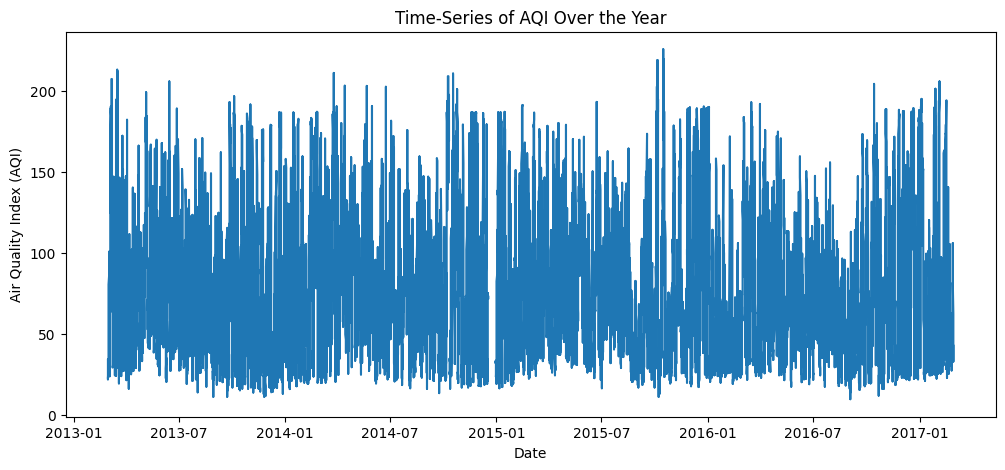

In [101]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['air_quality_index'])
plt.xlabel("Date")
plt.ylabel("Air Quality Index (AQI)")
plt.title("Time-Series of AQI Over the Year")
plt.savefig("time_series_aqi.png", dpi=300, bbox_inches='tight')
plt.show()

##### INSIGHTS : 

Seasonal patterns are visible. 

Higher AQI values are observed in winter months, 

indicating poor air quality during this period.

#### Pollutant Comparison:
##### • Create a box plot to compare the distribution of each pollutant (PM2.5, PM10,
NO2, O3) across different seasons.

##### • Write a short explanation of the insights derived from the box plot.

##### For PM2.5

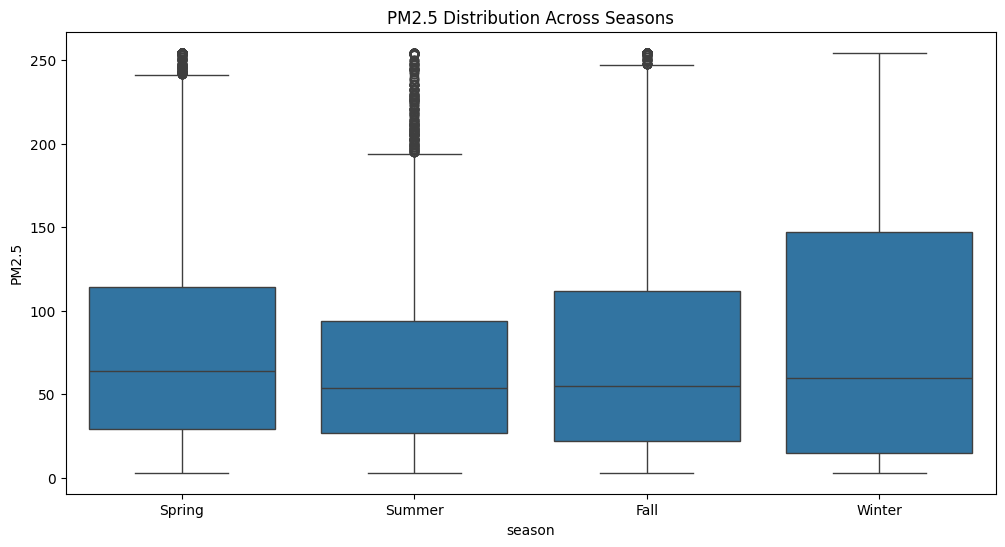

In [102]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='season', y='PM2.5')
plt.title("PM2.5 Distribution Across Seasons")
plt.savefig("pm25_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()



##### For PM10

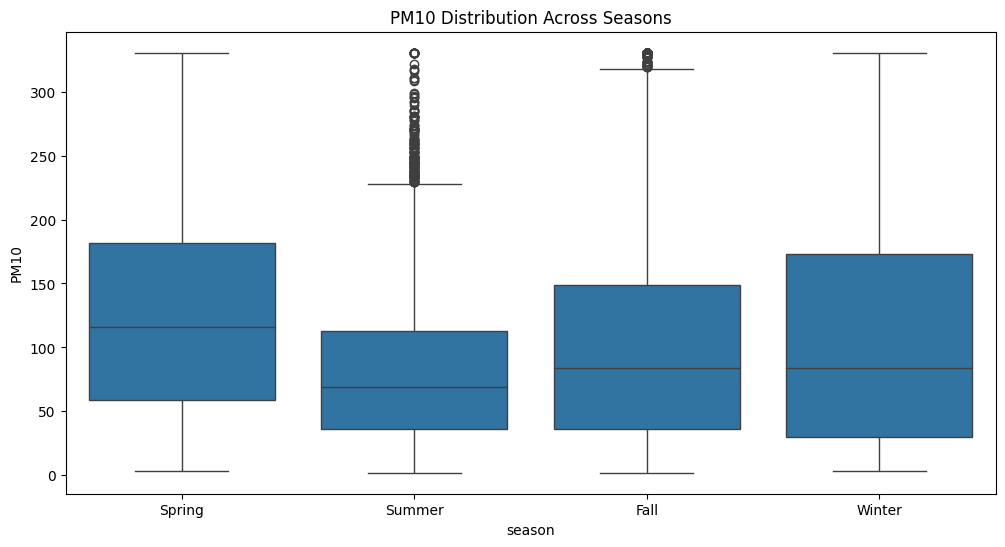

In [103]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='season', y='PM10')
plt.title("PM10 Distribution Across Seasons")
plt.savefig("pm10_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


##### For NO2

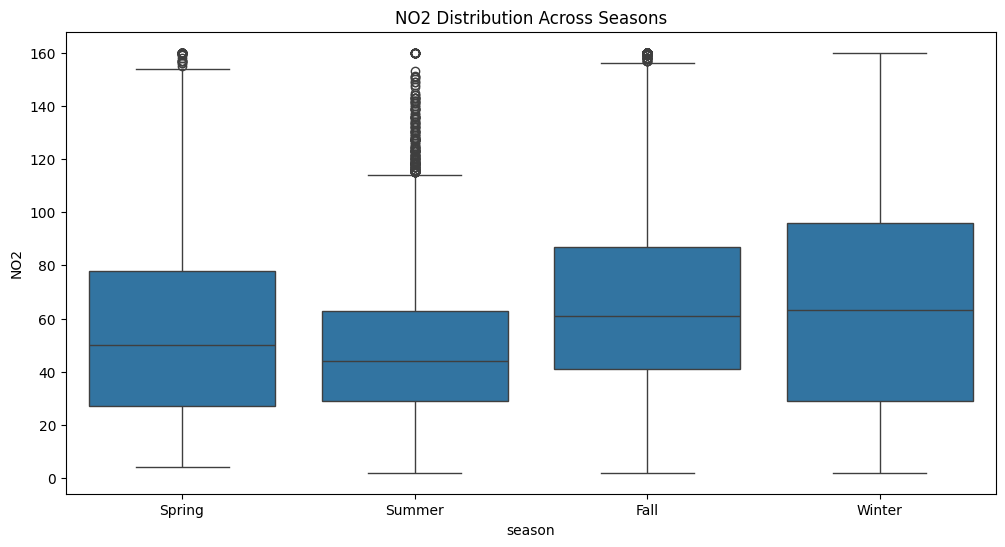

In [104]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='season', y='NO2')
plt.title("NO2 Distribution Across Seasons")
plt.savefig("no2_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


##### For O3

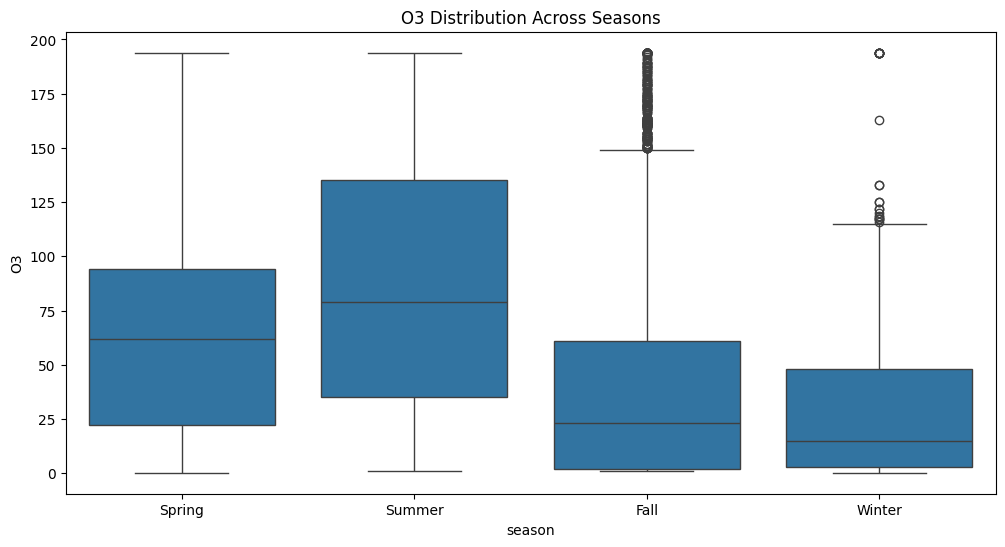

In [105]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='season', y='O3')
plt.title("O3 Distribution Across Seasons")
plt.savefig("o3_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


Insights to write:

 Boxplots show how each pollutant varies in each season.

 If winter boxes are higher ( winter pollution is worse).

 If monsoon has low values ( rainy season cleans the air).

 More outliers ( more unstable pollution levels ) .

#### Weather Impact on Air Quality:
##### • Create a scatter plot to explore the relationship between temperature and air_quality_index.
##### • Write a short explanation of the relationship observed.

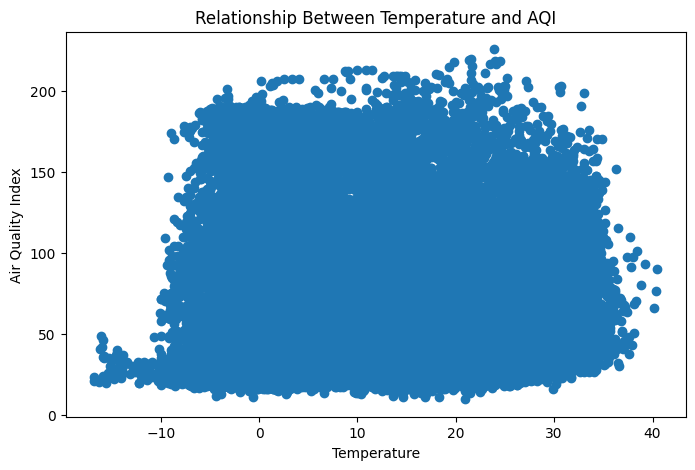

In [106]:
plt.figure(figsize=(8,5))
plt.scatter(df['TEMP'], df['air_quality_index'])
plt.xlabel("Temperature")
plt.ylabel("Air Quality Index")
plt.title("Relationship Between Temperature and AQI")
plt.savefig("temp_vs_aqi.png", dpi=300, bbox_inches='tight')
plt.show()


##### Insights

 Points going upward ( higher temperature associated with higher pollution).

 Points going downward (clean air in warmer weather).

 No pattern (no strong relationship).

### Pollution Level Analysis:

##### Create a bar plot showing the count of days in each pollution_level category (Good, Moderate, Unhealthy).

##### Write a short explanation of the insights derived from the bar plot.

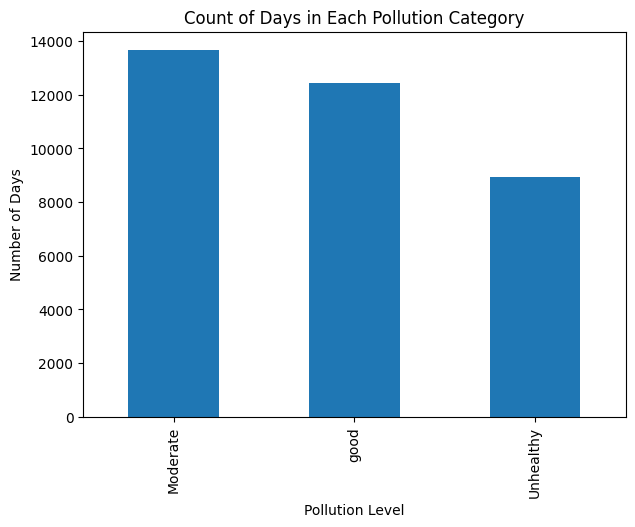

In [107]:
plt.figure(figsize=(7,5))
df['pollution_level'].value_counts().plot(kind='bar')
plt.title("Count of Days in Each Pollution Category")
plt.xlabel("Pollution Level")
plt.ylabel("Number of Days")
plt.savefig("pollution_level_bar.png", dpi=300, bbox_inches='tight')
plt.show()


##### Insights:
 
 Shows which category is most common.
 
 If “Moderate” is highest (general pollution but not severe daily).
 
 If “Unhealthy” has many days (public health concern).

#### Monthly Air Quality Patterns:

 ##### Create a box plot to visualize the distribution of air_quality_index for each month.
 
 ##### Write a short explanation of any repeated patterns or anomalies.

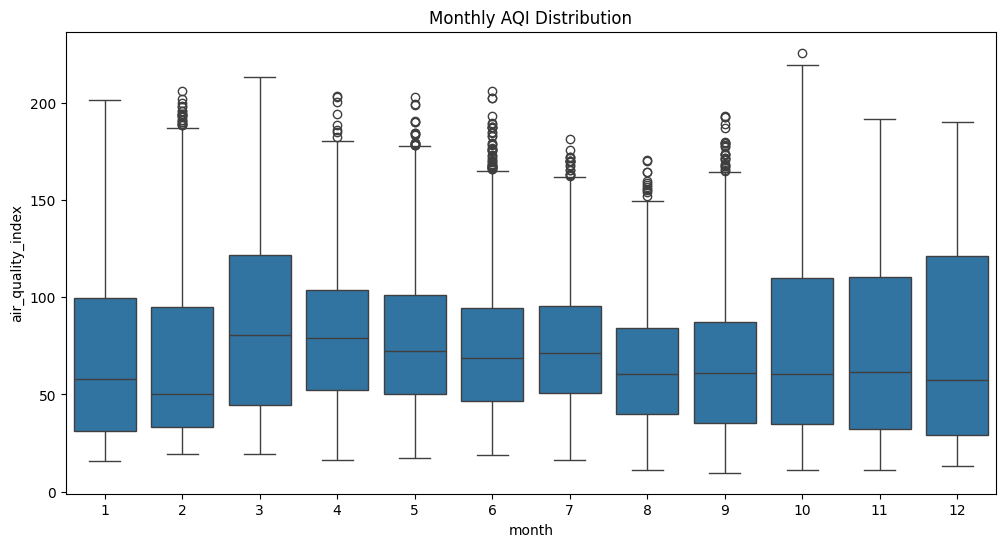

In [108]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='month', y='air_quality_index')
plt.title("Monthly AQI Distribution") 
plt.savefig("monthly_aqi_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()


##### Insights:

 Shows which months have high/low AQI.
 
 A rising or falling pattern ( seasonal effect ).
 
 Anomalies (very high values in unexpected months), special pollution events.